# Graph State & Reducers

## Review

In [2.simple_graph.ipynb](2.simple_graph.ipynb), we built a simple graph with nodes, normal edges, and conditional edges using a custom `TypedDict` as state.

## Goals

In this notebook we focus on **reducers** — the mechanism that controls *how* state is updated as a graph executes.

Key ideas:

* Without a reducer, each node **overwrites** the state key entirely
* A **reducer function** lets you define custom merge logic (e.g. append, sum, union)
* LangGraph provides the built-in `add_messages` reducer for the extremely common pattern of accumulating messages
* `MessagesState` is a pre-built state class that uses `add_messages` under the hood

In [1]:
%run ../langchain_common.py

C:\Users\akhawaja\git\cs4603\langchain_common.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from typing_extensions import TypedDict
from typing import Annotated
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## The Problem: Default Overwrite Behaviour

By default, when a node returns a value for a state key, it **replaces** the previous value entirely. This is fine for scalar values, but problematic when you want to *accumulate* data (like a growing list of messages).

In [3]:
# State WITHOUT a reducer — values get overwritten
class OverwriteState(TypedDict):
    value: int

def node_a(state: OverwriteState):
    print(f"  node_a sees value = {state['value']}")
    return {"value": state["value"] + 1}

def node_b(state: OverwriteState):
    print(f"  node_b sees value = {state['value']}")
    return {"value": state["value"] + 10}

builder = StateGraph(OverwriteState)
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", END)
graph = builder.compile()

result = graph.invoke({"value": 0})
print(f"\nFinal state: {result}")
# value goes 0 → 1 → 11 (each node overwrites with its return value)

  node_a sees value = 0
  node_b sees value = 1

Final state: {'value': 11}


## What is a Reducer?

A **reducer** is a function attached to a state key that controls how updates are merged.

```python
def my_reducer(existing_value, new_value):
    # return the merged result
    ...
```

You attach a reducer using `Annotated`:

```python
class MyState(TypedDict):
    items: Annotated[list[str], my_reducer]
```

When a node returns `{"items": ["new_item"]}`, LangGraph calls `my_reducer(existing_items, ["new_item"])` instead of simply overwriting.

## Example: A Custom List Reducer

Let's build a graph where multiple nodes each append items to a shared list. We'll use `operator.add` (which concatenates lists) as our reducer.

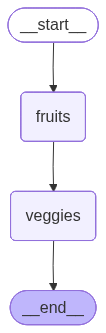

In [ ]:
import operator

class ListState(TypedDict):
   items: Annotated[list[str], operator.add]  # reducer = list concatenation
   # items: list[str] # without reducer, values get overwritten

def gather_fruits(state: ListState):
    return {"items": ["apple", "banana"]}

def gather_veggies(state: ListState):
    return {"items": ["carrot", "spinach"]}

builder = StateGraph(ListState)
builder.add_node("fruits", gather_fruits)
builder.add_node("veggies", gather_veggies)
builder.add_edge(START, "fruits")
builder.add_edge("fruits", "veggies")
builder.add_edge("veggies", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
result = graph.invoke({"items": []})
print(result)
# Both nodes' items are accumulated: ['apple', 'banana', 'carrot', 'spinach']

{'items': ['carrot', 'spinach']}


Without the reducer, only the last node's return would survive. With `operator.add`, both contributions are merged.

## Other Reducer Patterns

You can use any callable as a reducer. Common patterns:

| Reducer | Effect |
|---------|--------|
| `operator.add` | Concatenate lists / sum numbers |
| `lambda old, new: old \| new` | Merge sets or dicts |
| `lambda old, new: new` | Explicit overwrite (the default) |
| Custom function | Any merge logic you need |

In [8]:
# Example: a reducer that sums integers
class CounterState(TypedDict):
    total: Annotated[int, operator.add]

def add_five(state: CounterState):
    return {"total": 5}

def add_three(state: CounterState):
    return {"total": 3}

builder = StateGraph(CounterState)
builder.add_node("add_five", add_five)
builder.add_node("add_three", add_three)
builder.add_edge(START, "add_five")
builder.add_edge("add_five", "add_three")
builder.add_edge("add_three", END)
graph = builder.compile()

result = graph.invoke({"total": 0})
print(f"Total = {result['total']}")  # 0 + 5 + 3 = 8

Total = 8


## The `add_messages` Reducer

The most important built-in reducer in LangGraph is `add_messages`.

In LLM applications, state is almost always a **growing list of messages** (human → AI → human → AI …). Each node appends new messages rather than replacing the conversation.

`add_messages` handles this by:
- Appending new messages to the existing list
- Handling message deduplication by ID (useful for edits/updates)

In [9]:
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages

# Manually demonstrate add_messages as a function
existing = [HumanMessage(content="Hi there!", name="User")]
new = [AIMessage(content="Hello! How can I help?", name="Model")]

merged = add_messages(existing, new)
for m in merged:
    m.pretty_print()

================================ Human Message =================================
Name: User

Hi there!
================================== Ai Message ==================================
Name: Model

Hello! How can I help?


In [10]:
# Calling add_messages again appends further
more = [HumanMessage(content="Tell me about reducers in LangGraph.", name="User")]
merged = add_messages(merged, more)
for m in merged:
    m.pretty_print()

================================ Human Message =================================
Name: User

Hi there!
================================== Ai Message ==================================
Name: Model

Hello! How can I help?
================================ Human Message =================================
Name: User

Tell me about reducers in LangGraph.


## Using `add_messages` in State

We annotate the `messages` key with `add_messages` so every node's returned messages are *appended* to the conversation.

In [11]:
class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

## Pre-built `MessagesState`

Since a messages list with `add_messages` is so common, LangGraph provides it out of the box:

```python
from langgraph.graph import MessagesState
```

It is defined as:
```python
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

You can extend it if you need additional state keys:

In [12]:
from langgraph.graph import MessagesState

class MyState(MessagesState):
    # messages key with add_messages reducer is inherited
    summary: str  # additional key (no reducer → overwrite by default)

## Putting It Together: A Graph with `MessagesState`

Let's build a two-node graph where:
1. The first node adds a greeting from the AI
2. The second node adds a follow-up question

Both messages accumulate in state thanks to the `add_messages` reducer.

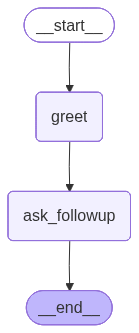

In [13]:
def greet(state: MessagesState):
    return {"messages": [AIMessage(content="Hello! I'm your assistant.")]}

def ask_followup(state: MessagesState):
    return {"messages": [AIMessage(content="What would you like to know about today?")]}

builder = StateGraph(MessagesState)
builder.add_node("greet", greet)
builder.add_node("ask_followup", ask_followup)
builder.add_edge(START, "greet")
builder.add_edge("greet", "ask_followup")
builder.add_edge("ask_followup", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# Invoke with a user message — all 3 messages accumulate
result = graph.invoke({"messages": [HumanMessage(content="Hi there!")]})
print(f"Total messages in state: {len(result['messages'])}\n")
for m in result["messages"]:
    m.pretty_print()

Total messages in state: 3

================================ Human Message =================================

Hi there!
================================== Ai Message ==================================

Hello! I'm your assistant.
================================== Ai Message ==================================

What would you like to know about today?


## Key Takeaways

| Concept | What it does |
|---------|-------------|
| No reducer | Node output **overwrites** the state key |
| `Annotated[type, reducer_fn]` | Node output is **merged** via `reducer_fn(old, new)` |
| `operator.add` | Concatenates lists or sums numbers |
| `add_messages` | Appends messages (with ID-based dedup) |
| `MessagesState` | Pre-built state with `messages: Annotated[list, add_messages]` |

Reducers are the foundation for building agents that accumulate context across multiple reasoning steps — which we'll use in the next notebooks on routers and agents.